In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

features = ['T_SRS_AWR', 'T_SRS_COG', 'T_SRS_COMM', 'T_SRS_MOT', 'T_SRS_RRB',
            'CBCL_AP_T', 'CBCL_Externalizing_T',
            'ASC_PA', 'ASC_AA', 'ASC_SA', 'ASC_uncertainty',
            'M_SEQ_hypo', 'M_SEQ_hyper', 'M_SEQ_seeking']
round_cols = ['T_SRS_AWR', 'T_SRS_COG', 'T_SRS_COMM', 'T_SRS_MOT', 'T_SRS_RRB',
              'CBCL_AP_T', 'CBCL_Externalizing_T', 'ASC_PA', 'ASC_AA',
              'ASC_SA', 'ASC_uncertainty']

# Run with the notebook folder as the working directory.
df = pd.read_excel('metadata_diet_per_cal.xlsx').query("Cohort == 'A'").reset_index(drop=True)
baseline = df['Cluster'].to_numpy()
classes = np.array(['Mild', 'Moderate', 'Severe'])
X = pd.DataFrame(KNNImputer(n_neighbors=2).fit_transform(df[features]), columns=features)
X[round_cols] = X[round_cols].round()
X = StandardScaler().fit_transform(X)

In [2]:
scores = []
for seed in range(500):
    model = KMeans(n_clusters=3, random_state=seed, n_init='auto').fit(X)
    order = np.argsort(model.cluster_centers_.mean(axis=1))
    mapping = dict(zip(order, classes))
    labeled = np.array([mapping[i] for i in model.labels_])
    scores.append([seed, adjusted_rand_score(baseline, labeled), np.mean(labeled == baseline)])

results = pd.DataFrame(scores, columns=['seed', 'ARI', 'rule_accuracy'])
results[['ARI', 'rule_accuracy']].agg(['mean', 'std', 'min', 'max'])

,ARI,rule_accuracy
mean,0.885620,0.961319
std,0.038833,0.012896
min,0.842409,0.948611
max,1.000000,1.000000


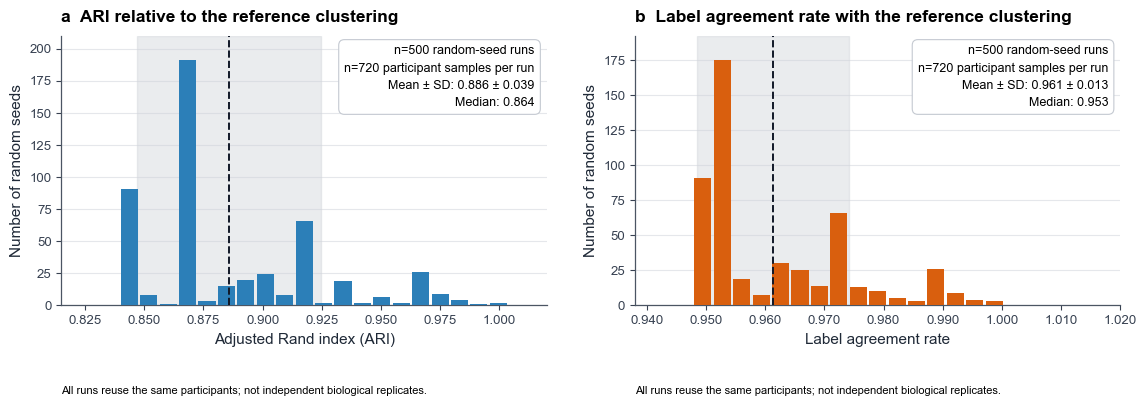

In [3]:
import matplotlib.ticker as mticker
from pathlib import Path

# Plot styling with editable vector text.
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 12.5,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelcolor': '#1F2937',
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'axes.edgecolor': '#4B5563',
    'axes.linewidth': 0.9,
    'axes.unicode_minus': False,
    'svg.fonttype': 'none',            # Preserve editable SVG text.
    'pdf.fonttype': 42,                # Embed TrueType fonts in PDF.
    'savefig.dpi': 300,
})

PANEL_COLOR = {'ARI': '#2C7FB8', 'rule_accuracy': '#D95F0E'}


def draw_panel(ax, col, title, xlabel, color, xlim, bins=25):
    vals = results[col].to_numpy()
    assert np.isfinite(vals).all() and results['seed'].is_unique
    mean, std = vals.mean(), vals.std()
    xlim = (min(xlim[0], vals.min()), max(xlim[1], vals.max()))
    edges = np.linspace(xlim[0], xlim[1], bins + 1)
    # Bar width is 88% of the histogram bin width.
    counts, bin_edges = np.histogram(vals, bins=edges)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.bar(centers, counts, width=(bin_edges[1] - bin_edges[0]) * 0.88,
           align='center', color=color, zorder=3)
    assert counts.sum() == len(vals)
    ax.axvspan(mean - std, mean + std, color='#D1D5DB', alpha=0.45, zorder=1)
    ax.axvline(mean, color='#111827', linestyle='--', linewidth=1.4, zorder=4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#E5E7EB', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(title, loc='left', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of random seeds')
    ax.set_xlim(xlim)
    ax.set_ylim(0, max(counts.max() * 1.1, 1))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.text(0.975, 0.965,
            f'n={len(vals)} random-seed runs\n'
            f'n={len(df)} participant samples per run\n'
            f'Mean \u00b1 SD: {mean:.3f} \u00b1 {std:.3f}\n'
            f'Median: {np.median(vals):.3f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            linespacing=1.55,
            bbox=dict(boxstyle='round,pad=0.45', fc='white', ec='#C4C9D1', lw=0.8),
            zorder=5)
    ax.text(0, -0.30, 'All runs reuse the same participants; not independent biological replicates.',
            transform=ax.transAxes, ha='left', va='top', fontsize=8)


OUT_DIR = Path('figures_kmeans_stability')
OUT_DIR.mkdir(exist_ok=True)
BASE = OUT_DIR / 'kmeans_seed_stability_500'

# Combined two-panel figure.
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
for ax, (col, title, xlabel, color, xlim) in zip(axes, [
    ('ARI', 'a  ARI relative to the reference clustering',
     'Adjusted Rand index (ARI)', PANEL_COLOR['ARI'], (0.815, 1.02)),
    ('rule_accuracy', 'b  Label agreement rate with the reference clustering',
     'Label agreement rate', PANEL_COLOR['rule_accuracy'], (0.938, 1.02)),
]):
    draw_panel(ax, col, title, xlabel, color, xlim)
fig.tight_layout(w_pad=2.4)
for ext in ('pdf', 'png'):
    fig.savefig(f'{BASE}.{ext}', bbox_inches='tight', facecolor='white')

# Individual panels for publication layout.
for stem, col, title, xlabel, color, xlim in [
    ('panel_a_ARI', 'ARI', 'ARI relative to the reference clustering',
     'Adjusted Rand index (ARI)', PANEL_COLOR['ARI'], (0.815, 1.02)),
    ('panel_b_agreement', 'rule_accuracy',
     'Label agreement rate with the reference clustering',
     'Label agreement rate', PANEL_COLOR['rule_accuracy'], (0.938, 1.02)),
]:
    f, ax = plt.subplots(figsize=(6.4, 4.4))
    draw_panel(ax, col, title, xlabel, color, xlim)
    f.tight_layout()
    for ext in ('pdf', 'png'):
        f.savefig(OUT_DIR / f'{stem}.{ext}', bbox_inches='tight', facecolor='white')
    plt.close(f)

plt.show()